In [2]:
words = open('names.txt', 'r').read().splitlines()

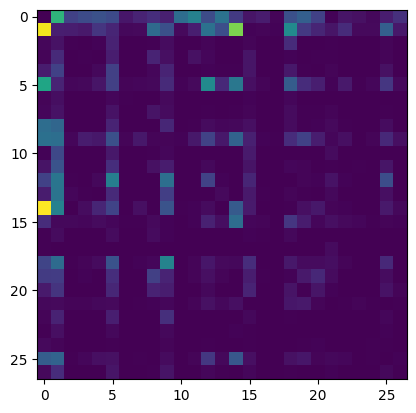

In [3]:
import torch
import matplotlib.pyplot as plt

alphabet = sorted(list(set(''.join(words)+'$')))
counts = torch.ones([len(alphabet), len(alphabet)], dtype=torch.int32)
stoi = {s:i for i, s in enumerate(alphabet)}

for w in words:
	padded = '$'+w+'$'
	for a, b in zip(padded, padded[1:]):
		counts[stoi[a]][stoi[b]]+=1


 
plt.imshow(counts)

In [4]:
P = counts.float()
P /= P.sum(1, keepdim=True) # 27 x 1

In [5]:
g = torch.Generator().manual_seed(5)

for _ in range(30):
	out = []
	ix = 0
	while True:
		p = P[ix]

		# p = counts[ix].float()
		# # p = torch.ones(len(alphabet))
		# p /= p.sum()
		ix = int(torch.multinomial(p, num_samples=1, replacement=True, generator=g)[0].item())
		out.append(alphabet[ix])
		if (ix == 0):
			break

	print(''.join(out));


a$
xyam$
tyari$
zas$
phisy$
anyvyiahusgael$
sonazellecyntestri$
s$
ayaveyannehoueyn$
nanyokotanayee$
lyannke$
ssstorami$
dishumama$
carariyn$
maya$
gos$
ten$
memirmeli$
sa$
jil$
kana$
poberlelileselen$
ktulayannteunas$
mmai$
keyanzylyrailiavnan$
kyn$
ckiyah$
ener$
kly$
jasahavatemet$


In [6]:
# negative log likelihood
# We need a loss function. Let's look at for a series of bigrams, what did we expect them to be
import math

words[:3]
log_likelihood = 0
n=0
for w in words:
	padded = '$'+w+'$'
	for ch1, ch2 in zip(padded, padded[1:]):
		n+=1
		ind1 = stoi[ch1]
		ind2 = stoi[ch2]
		log_likelihood += math.log(P[ind1, ind2])
		# print(f'{ch1} {ch2} - {P[ind1, ind2]}' )

nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

# our goal is to minimize negative log likelihood, so that's our loss function

nll=560001.8836078098
2.4545768218939177


In [7]:
# Now let's make a training set
input_xs, input_ys = [], []

for w in words[:1]:
	padded = '$'+w+'$'
	for ch1, ch2 in zip(padded, padded[1:]):
		ix1 = stoi[ch1]
		ix2 = stoi[ch2]
		input_xs.append(ix1)
		input_ys.append(ix2)


xs: torch.Tensor = torch.tensor(input_xs)
ys: torch.Tensor = torch.tensor(input_ys)
xs

tensor([ 0,  5, 13, 13,  1])

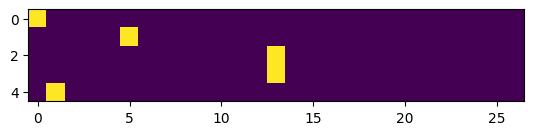

In [8]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
xenc.shape
plt.imshow(xenc)

In [9]:
xenc.shape

torch.Size([5, 27])

In [10]:
from typing import cast

G = torch.Generator().manual_seed(5)

W = torch.randn((27, 27), generator=G, requires_grad=True)



# this evaluates for each input, dot it with each neuron, and add them up
# (xenc @ W)[3, 13] is the third input, dotted with the 13th neuron

# we read this as log counts. Then we'll exponentiate them, and then make a probability distribution out of that

In [11]:
# 5x27  27x27
logits = (xenc @ W)
exponentiated = logits.exp()
props = exponentiated / exponentiated.sum(1, keepdim=True)
log_likelihood_mean = props[torch.arange(5), ys].log().mean()

nll = -log_likelihood_mean;
W.grad = None
nll.backward()
assert isinstance(W.grad, torch.Tensor)
W.data += W.grad *-0.001
nll


tensor(4.8163, grad_fn=<NegBackward0>)

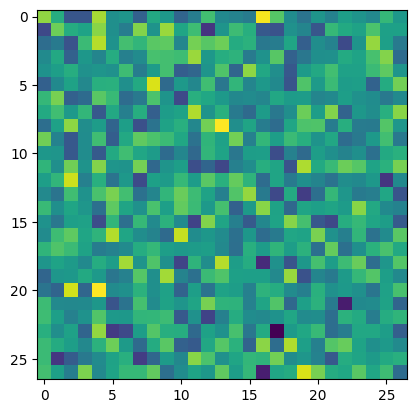

In [12]:
plt.imshow(W.data)